# Correlation

## Figure 5

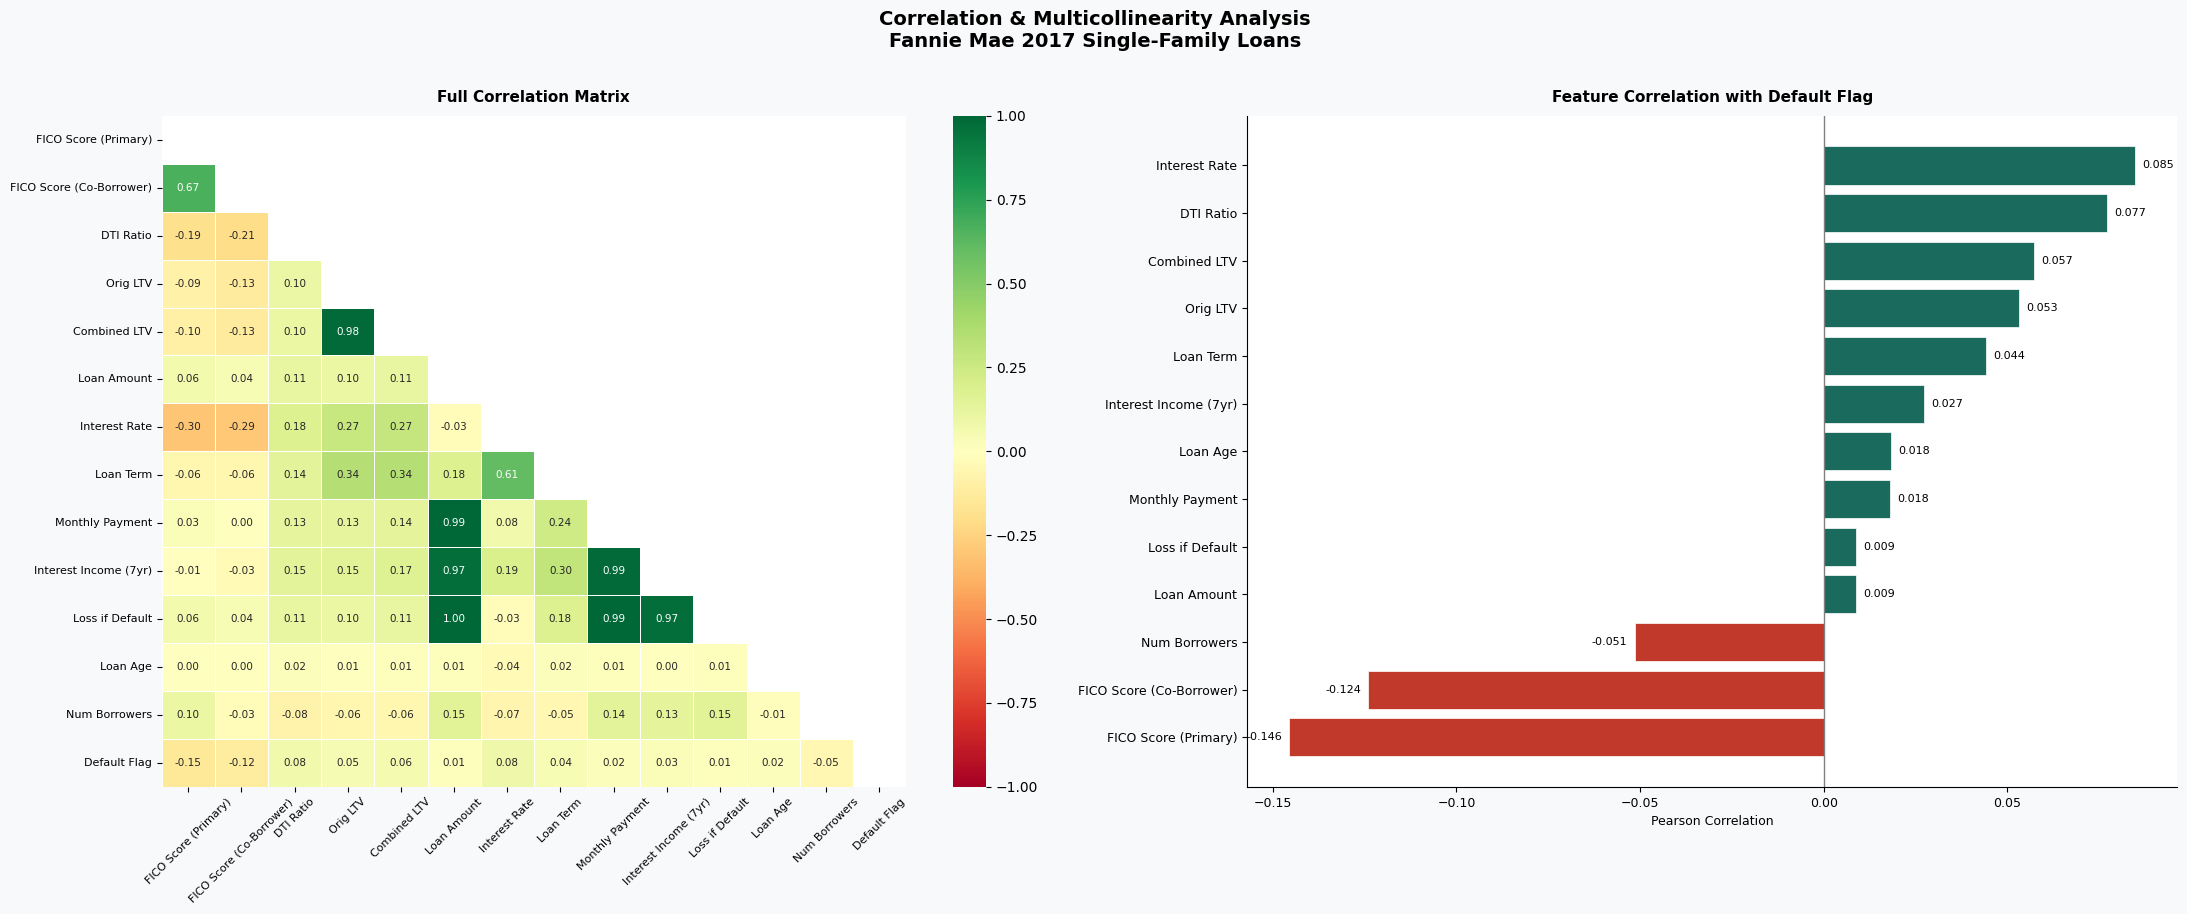

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet('../data/processed/fannie_2017_clean.parquet') 

num_cols = ['CSCORE_B', 'CSCORE_C', 'DTI', 'OLTV', 'OCLTV', 'ORIG_UPB', 'ORIG_RATE',
            'ORIG_TERM', 'monthly_payment', 'interest_income_7yr',
            'loss_if_default', 'LOAN_AGE', 'NUM_BO', 'default_flag']

for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

corr = df[num_cols].corr()

rename = {
    'CSCORE_B':            'FICO Score (Primary)',
    'CSCORE_C':            'FICO Score (Co-Borrower)',
    'DTI':                 'DTI Ratio',
    'OLTV':                'Orig LTV',
    'OCLTV':               'Combined LTV',
    'ORIG_UPB':            'Loan Amount',
    'ORIG_RATE':           'Interest Rate',
    'ORIG_TERM':           'Loan Term',
    'monthly_payment':     'Monthly Payment',
    'interest_income_7yr': 'Interest Income (7yr)',
    'loss_if_default':     'Loss if Default',
    'LOAN_AGE':            'Loan Age',
    'NUM_BO':              'Num Borrowers',
    'default_flag':        'Default Flag',
}
corr = corr.rename(index=rename, columns=rename)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.patch.set_facecolor('#f8f9fa')
fig.suptitle(
    'Correlation & Multicollinearity Analysis\n'
    'Fannie Mae 2017 Single-Family Loans',
    fontsize=14, fontweight='bold', y=1.01
)

# LEFT: full lower-triangle heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 7.5}, ax=axes[0]
)
axes[0].set_title('Full Correlation Matrix', fontsize=11, fontweight='bold', pad=10)
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)
axes[0].set_facecolor('white')

# RIGHT: correlation with default flag only 
target_corr = corr['Default Flag'].drop('Default Flag').sort_values()
colors = ['#c0392b' if v < 0 else '#1a6b5e' for v in target_corr]

axes[1].barh(target_corr.index, target_corr.values, color=colors,
             edgecolor='white', linewidth=0.5)
axes[1].axvline(x=0, color='gray', linewidth=1)
axes[1].set_title('Feature Correlation with Default Flag',
                  fontsize=11, fontweight='bold', pad=10)
axes[1].set_xlabel('Pearson Correlation', fontsize=9)
axes[1].set_facecolor('white')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].tick_params(labelsize=9)

for i, val in enumerate(target_corr.values):
    axes[1].text(
        val + (0.002 if val >= 0 else -0.002), i,
        f'{val:.3f}',
        va='center', ha='left' if val >= 0 else 'right', fontsize=8
    )

plt.tight_layout()
plt.show()

**Observations**

Full Correlation Matrix (left):

- Orig LTV and Combined LTV are 0.98 correlated 
    - Nearly identical, drop Combined LTV from the ML model, keep Orig LTV
- Loan Amount, Monthly Payment, Interest Income (7yr), and Loss if Default form a tight cluster all 0.97-1.00 correlated with each other    
    - All measuring loan size in different ways, keep only Loan Amount for ML
- Interest Rate and Loan Term are 0.61 correlated
    - Moderate overlap but different enough to keep both
- Primary and co-borrower FICO are 0.67 correlated
    - Related but meaningfully independent, both worth keeping
- DTI and both FICO scores are only -0.19 to -0.21 
    - Largely independent signals, all three belong in the model

Feature Correlation with Default Flag (right):

- FICO Score (Primary) is the strongest predictor at -0.146 
    - Higher FICO = lower default
- FICO Score (Co-Borrower) second strongest at -0.124
    - Independent signal worth keeping despite 53% nulls
- Interest Rate (+0.085) and DTI (+0.077) are the strongest positive predictors
- Loan Age, Monthly Payment, Loss if Default, and Loan Amount are all near zero
    - Weak individual predictors